<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>



# Rekurencyjne Sieci Neuronowe - Zadanie

Głównym zadaniem jest stworzenie i wytrenowanie głębokiej rekurencyjnej sieci neuronowej zdolnej poprawnie rozwiązać jedno z zagadnień rozpoznawania mowy a mianowicie zagadnienie identyfikacji rozmówcy.

Dane uczące zawierają nagrania audio pochodzące z rozmowy pomiędzy osobą A i B (plik `dataset.zip` dołączony do zadania).

W trakcie realizacji zadania należy wykonań następujące podzadania:
1. Podzielić próbki na dane uczące i testowe.
2. Zdefiniować __dwa__ modele głebokiej rekurencyjnej sieci neuronowej według własnego pomysłu. W pierwszym modelu dzwięk reprezentowany powinien być za pomocą szeregu czasowego, a w drugim za pomocą spektogramu MFCC (warto wykorzystać pakiet [librosa](https://librosa.github.io/librosa/generated/librosa.feature.mfcc.html). Oba modele powinny rozwiązywać problem klasyfikacji, czy dana próbka pochodzi od osoby A czy B.
3. Wytrenować zdefiniowane sieci na danych uczących.
4. Ocenić skuteczność i porównać działanie modeli na danych testowych.
5. Najlepsze ze stworzonych modeli zapisać do pliku i przesłać na elf'a razem z notatnikiem.

__Polecam też rozszerzyć zbiór danych o nagrania własnego głosu.__

## Import bibliotek

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import librosa

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

from pathlib import Path

from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Input, Masking, LSTM, GRU, Dense, Dropout, Bidirectional
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

Numpy version: 2.4.2
Tensorflow version: 2.20.0
Keras version: 3.13.2


## Przygotowanie danych

In [40]:
DATA_PATH = Path.cwd().joinpath("dataset")
A_PATH = DATA_PATH / "A"
B_PATH = DATA_PATH / "B"

In [41]:
SR = 16000
SEGMENT_SEC = 0.1
HOP_SEC = 0.05

N_FFT = 400
HOP_LENGTH = 160
N_MFCC = 13

SEED = 143200  # nr albumu

np.random.seed(SEED)
tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)

In [42]:
def load_audio(path, sr=SR, trim=True, top_db=20):
    y, _ = librosa.load(path, sr=sr, mono=True)

    if trim:
        y, _ = librosa.effects.trim(y, top_db=top_db)

    max_abs = np.max(np.abs(y)) if len(y) > 0 else 0.0
    if max_abs > 0:
        y = y / max_abs

    return y.astype(np.float32)


def list_audio_files(folder: Path):
    exts = {".wav", ".mp3", ".flac", ".ogg", ".m4a"}
    return sorted(
        [p for p in folder.glob("*") if p.is_file() and p.suffix.lower() in exts]
    )


def split_one_class_3way(files, label, n_val=2, n_test=2, rng=None):
    files = np.array(files, dtype=object)
    n = len(files)

    if n < n_val + n_test + 1:
        raise ValueError(f"Za mało plików w klasie {label}: {n}")

    idx = np.arange(n)
    rng.shuffle(idx)

    val_idx = idx[:n_val]
    test_idx = idx[n_val : n_val + n_test]
    train_idx = idx[n_val + n_test :]

    X_train = files[train_idx]
    y_train = np.full(len(train_idx), label, dtype=np.int32)

    X_val = files[val_idx]
    y_val = np.full(len(val_idx), label, dtype=np.int32)

    X_test = files[test_idx]
    y_test = np.full(len(test_idx), label, dtype=np.int32)

    return X_train, y_train, X_val, y_val, X_test, y_test

In [43]:
def split_into_segments(y, sr=SR, segment_sec=SEGMENT_SEC, hop_sec=HOP_SEC):
    seg_len = int(segment_sec * sr)
    hop_len = int(hop_sec * sr)

    if len(y) == 0:
        return []

    if len(y) < seg_len:
        y = np.pad(y, (0, seg_len - len(y)))

    segments = []
    for start in range(0, len(y) - seg_len + 1, hop_len):
        seg = y[start : start + seg_len]
        segments.append(seg.astype(np.float32))

    return segments

In [44]:
def extract_time_features(segment, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH):
    rms = librosa.feature.rms(y=segment, frame_length=n_fft, hop_length=hop_length)[0]

    zcr = librosa.feature.zero_crossing_rate(
        segment, frame_length=n_fft, hop_length=hop_length
    )[0]

    centroid = librosa.feature.spectral_centroid(
        y=segment, sr=sr, n_fft=n_fft, hop_length=hop_length
    )[0]

    bandwidth = librosa.feature.spectral_bandwidth(
        y=segment, sr=sr, n_fft=n_fft, hop_length=hop_length
    )[0]

    feats = np.stack([rms, zcr, centroid, bandwidth], axis=1)
    return feats.astype(np.float32)

In [45]:
def extract_mfcc_features(
    segment, sr=SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH
):
    mfcc = librosa.feature.mfcc(
        y=segment, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length
    )
    return mfcc.T.astype(np.float32)  # (T, n_mfcc)

In [46]:
def build_segment_dataset(paths, labels, feature_fn):
    X, y = [], []

    for path, label in zip(paths, labels):
        audio = load_audio(path)
        segments = split_into_segments(audio)

        for seg in segments:
            feat = feature_fn(seg)
            X.append(feat)
            y.append(label)

    return X, np.array(y, dtype=np.int32)

In [47]:
a_files = list_audio_files(A_PATH)
b_files = list_audio_files(B_PATH)

Xa_train, ya_train, Xa_val, ya_val, Xa_test, ya_test = split_one_class_3way(
    a_files, label=0, n_val=2, n_test=2, rng=rng
)

Xb_train, yb_train, Xb_val, yb_val, Xb_test, yb_test = split_one_class_3way(
    b_files, label=1, n_val=2, n_test=2, rng=rng
)

X_train_paths = np.concatenate([Xa_train, Xb_train]).astype(object)
y_train = np.concatenate([ya_train, yb_train])

X_val_paths = np.concatenate([Xa_val, Xb_val]).astype(object)
y_val = np.concatenate([ya_val, yb_val])

X_test_paths = np.concatenate([Xa_test, Xb_test]).astype(object)
y_test = np.concatenate([ya_test, yb_test])

# tasowanie
train_perm = rng.permutation(len(X_train_paths))
val_perm = rng.permutation(len(X_val_paths))
test_perm = rng.permutation(len(X_test_paths))

X_train_paths, y_train = X_train_paths[train_perm], y_train[train_perm]
X_val_paths, y_val = X_val_paths[val_perm], y_val[val_perm]
X_test_paths, y_test = X_test_paths[test_perm], y_test[test_perm]

print(f"Liczba plików A: {len(a_files)}, B: {len(b_files)}")
print(f"TRAIN files: {len(X_train_paths)}")
print(f"VAL files:   {len(X_val_paths)}")
print(f"TEST files:  {len(X_test_paths)}")

Liczba plików A: 30, B: 23
TRAIN files: 45
VAL files:   4
TEST files:  4


In [48]:
# =================================== #
# Dataset dla modelu 1: cechy czasowe #
# =================================== #
X_train_time_list, y_train_time = build_segment_dataset(
    X_train_paths, y_train, extract_time_features
)
X_val_time_list, y_val_time = build_segment_dataset(
    X_val_paths, y_val, extract_time_features
)
X_test_time_list, y_test_time = build_segment_dataset(
    X_test_paths, y_test, extract_time_features
)

print("Model czasowy:")
print("Train segments:", len(X_train_time_list))
print("Val segments:  ", len(X_val_time_list))
print("Test segments: ", len(X_test_time_list))


# ========================== #
# Dataset dla modelu 2: MFCC #
# ========================== #
X_train_mfcc_list, y_train_mfcc = build_segment_dataset(
    X_train_paths, y_train, extract_mfcc_features
)
X_val_mfcc_list, y_val_mfcc = build_segment_dataset(
    X_val_paths, y_val, extract_mfcc_features
)
X_test_mfcc_list, y_test_mfcc = build_segment_dataset(
    X_test_paths, y_test, extract_mfcc_features
)

print("\nModel MFCC:")
print("Train segments:", len(X_train_mfcc_list))
print("Val segments:  ", len(X_val_mfcc_list))
print("Test segments: ", len(X_test_mfcc_list))

Model czasowy:
Train segments: 2776
Val segments:   312
Test segments:  426

Model MFCC:
Train segments: 2776
Val segments:   312
Test segments:  426


In [49]:
def pad_feature_sequences(X_list, dtype=np.float32):
    max_len = max(x.shape[0] for x in X_list)
    feat_dim = X_list[0].shape[1]

    X_pad = np.zeros((len(X_list), max_len, feat_dim), dtype=dtype)

    for i, x in enumerate(X_list):
        X_pad[i, : x.shape[0], :] = x

    return X_pad


# czasowe
X_train_time = pad_feature_sequences(X_train_time_list)
X_val_time = pad_feature_sequences(X_val_time_list)
X_test_time = pad_feature_sequences(X_test_time_list)

# mfcc
X_train_mfcc = pad_feature_sequences(X_train_mfcc_list)
X_val_mfcc = pad_feature_sequences(X_val_mfcc_list)
X_test_mfcc = pad_feature_sequences(X_test_mfcc_list)

print("X_train_time shape:", X_train_time.shape)
print("X_train_mfcc shape:", X_train_mfcc.shape)

X_train_time shape: (2776, 11, 4)
X_train_mfcc shape: (2776, 11, 13)


In [50]:
def fit_standardizer(X):
    mean = X.mean(axis=(0, 1), keepdims=True)
    std = X.std(axis=(0, 1), keepdims=True) + 1e-8
    return mean, std


def apply_standardizer(X, mean, std):
    return (X - mean) / std


# dla cech czasowych
time_mean, time_std = fit_standardizer(X_train_time)
X_train_time = apply_standardizer(X_train_time, time_mean, time_std)
X_val_time = apply_standardizer(X_val_time, time_mean, time_std)
X_test_time = apply_standardizer(X_test_time, time_mean, time_std)

# dla MFCC
mfcc_mean, mfcc_std = fit_standardizer(X_train_mfcc)
X_train_mfcc = apply_standardizer(X_train_mfcc, mfcc_mean, mfcc_std)
X_val_mfcc = apply_standardizer(X_val_mfcc, mfcc_mean, mfcc_std)
X_test_mfcc = apply_standardizer(X_test_mfcc, mfcc_mean, mfcc_std)

## Definicja i trenowanie modeli

In [51]:
def build_time_model(input_shape):
    model = Sequential(
        [
            Input(shape=input_shape),
            Masking(mask_value=0.0),
            Bidirectional(LSTM(64, return_sequences=True)),
            Dropout(0.3),
            Bidirectional(LSTM(32, return_sequences=False)),
            Dropout(0.3),
            Dense(32, activation="relu"),
            Dropout(0.2),
            Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [52]:
def build_mfcc_model(input_shape):
    model = Sequential(
        [
            Input(shape=input_shape),
            Masking(mask_value=0.0),
            Bidirectional(GRU(64, return_sequences=True)),
            Dropout(0.3),
            Bidirectional(GRU(32, return_sequences=False)),
            Dropout(0.3),
            Dense(32, activation="relu"),
            Dropout(0.2),
            Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [53]:
callbacks_time = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        "best_time_model.keras", monitor="val_loss", save_best_only=True, verbose=1
    ),
]

callbacks_mfcc = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        "best_mfcc_model.keras", monitor="val_loss", save_best_only=True, verbose=1
    ),
]

In [54]:
time_model = build_time_model(input_shape=X_train_time.shape[1:])
mfcc_model = build_mfcc_model(input_shape=X_train_mfcc.shape[1:])

print("=== TIME MODEL ===")
time_model.summary()

print("\n=== MFCC MODEL ===")
mfcc_model.summary()

=== TIME MODEL ===


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_4 (Masking)             │ (None, 11, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 11, 128)        │        35,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,657 (307.25 KB)

 Trainable params: 78,657 (307.25 KB)

...

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_5 (Masking)             │ (None, 11, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 11, 128)        │        30,336 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 64)             │        31,104 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,553 (248.25 KB)

 Trainable params: 63,553 (248.25 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
history_time = time_model.fit(
    X_train_time,
    y_train_time,
    validation_data=(X_val_time, y_val_time),
    epochs=50,
    batch_size=8,
    callbacks=callbacks_time,
    verbose=1,
)

Epoch 1/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8076 - loss: 0.4680
Epoch 1: val_loss improved from None to 0.37492, saving model to best_time_model.keras

Epoch 1: finished saving model to best_time_model.keras
347/347 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8267 - loss: 0.4152 - val_accuracy: 0.8109 - val_loss: 0.3749
Epoch 2/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8440 - loss: 0.3777
Epoch 2: val_loss improved from 0.37492 to 0.34054, saving model to best_time_model.keras

Epoch 2: finished saving model to best_time_model.keras
347/347 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8487 - loss: 0.3703 - val_accuracy: 0.8269 - val_loss: 0.3405
Epoch 3/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8429 - loss: 0.3686
Epoch 3: val_loss improved from 0.34054 to 0.32678, saving model to best_time_model.keras

Epoch 3: finished saving model to best_time_model.keras
347/347 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8491 - l

In [56]:
history_mfcc = mfcc_model.fit(
    X_train_mfcc,
    y_train_mfcc,
    validation_data=(X_val_mfcc, y_val_mfcc),
    epochs=50,
    batch_size=8,
    callbacks=callbacks_mfcc,
    verbose=1,
)

Epoch 1/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9175 - loss: 0.2227
Epoch 1: val_loss improved from None to 0.02959, saving model to best_mfcc_model.keras

Epoch 1: finished saving model to best_mfcc_model.keras
347/347 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9575 - loss: 0.1204 - val_accuracy: 0.9904 - val_loss: 0.0296
Epoch 2/50
346/347 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9834 - loss: 0.0480
Epoch 2: val_loss did not improve from 0.02959
347/347 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9867 - loss: 0.0401 - val_accuracy: 0.9712 - val_loss: 0.0692
Epoch 3/50
347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9859 - loss: 0.0446
Epoch 3: val_loss did not improve from 0.02959
347/347 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9899 - loss: 0.0322 - val_accuracy: 0.9776 - val_loss: 0.0659
Epoch 4/50
345/347 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9885 - loss: 0.0353
Epoch 4: val_loss did not improve from 0.02959
347/347 ━━━━

## Ocena skuteczności

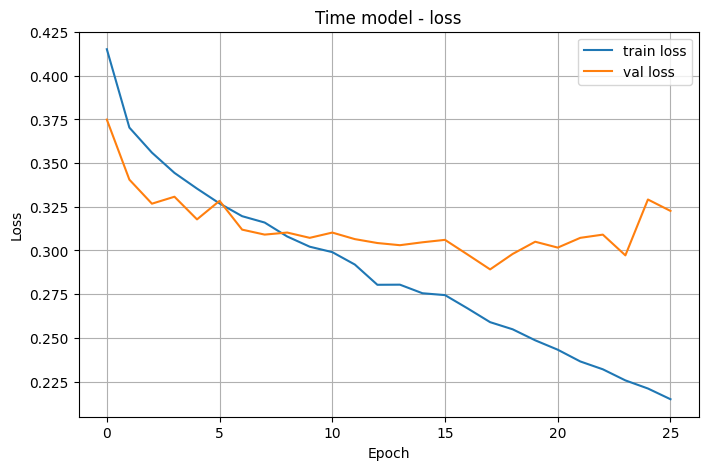

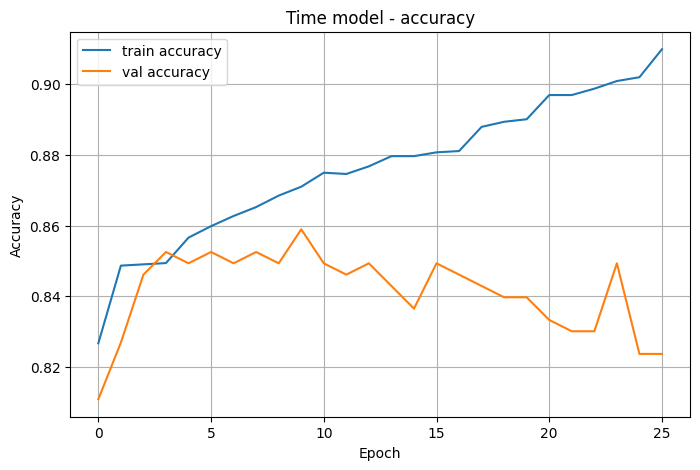

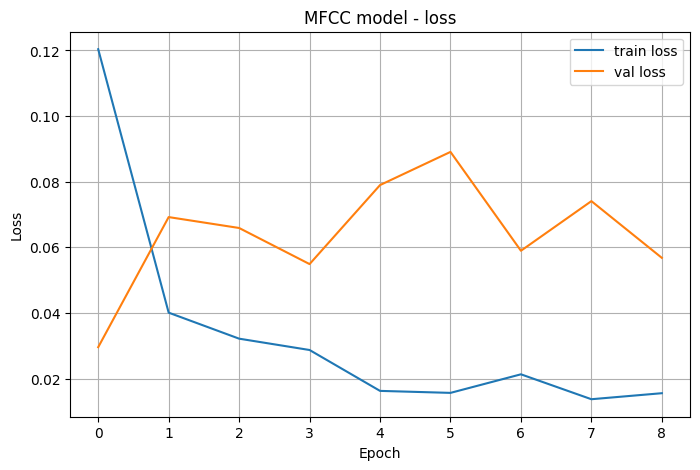

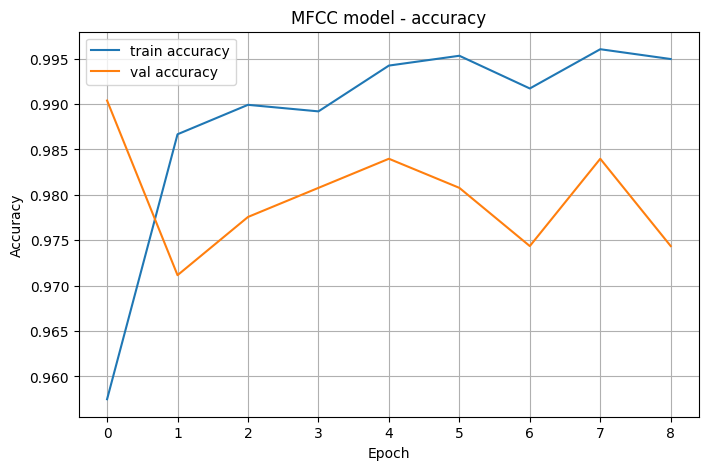

In [57]:
def plot_history(history, title="Training history"):
    hist = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="train loss")
    plt.plot(hist["val_loss"], label="val loss")
    plt.title(f"{title} - loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="train accuracy")
    plt.plot(hist["val_accuracy"], label="val accuracy")
    plt.title(f"{title} - accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(history_time, title="Time model")
plot_history(history_mfcc, title="MFCC model")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

=== Time model ===
Test loss: 0.2722
Test accuracy: 0.8873

Classification report:
              precision    recall  f1-score   support

           0     0.6957    0.8602    0.7692        93
           1     0.9582    0.8949    0.9255       333

    accuracy                         0.8873       426
   macro avg     0.8269    0.8776    0.8473       426
weighted avg     0.9009    0.8873    0.8914       426



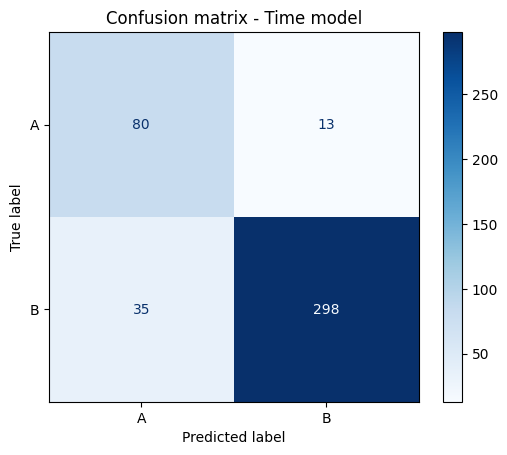

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

=== MFCC model ===
Test loss: 0.0291
Test accuracy: 0.9859

Classification report:
              precision    recall  f1-score   support

           0     0.9394    1.0000    0.9688        93
           1     1.0000    0.9820    0.9909       333

    accuracy                         0.9859       426
   macro avg     0.9697    0.9910    0.9798       426
weighted avg     0.9868    0.9859    0.9861       426



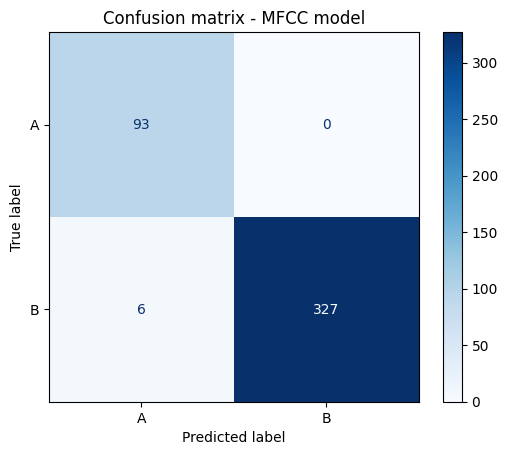

In [58]:
def evaluate_binary_model(model, X_test, y_test, threshold=0.5, model_name="Model"):
    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob >= threshold).astype(np.int32)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\n=== {model_name} ===")
    print(f"Test loss: {loss:.4f}")
    print(f"Test accuracy: {acc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["A", "B"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion matrix - {model_name}")
    plt.show()

    return y_prob, y_pred


y_prob_time, y_pred_time = evaluate_binary_model(
    time_model, X_test_time, y_test_time, threshold=0.5, model_name="Time model"
)

y_prob_mfcc, y_pred_mfcc = evaluate_binary_model(
    mfcc_model, X_test_mfcc, y_test_mfcc, threshold=0.5, model_name="MFCC model"
)

In [59]:
time_test_loss, time_test_acc = time_model.evaluate(X_test_time, y_test_time, verbose=0)
mfcc_test_loss, mfcc_test_acc = mfcc_model.evaluate(X_test_mfcc, y_test_mfcc, verbose=0)

print("\n=== PORÓWNANIE MODELI ===")
print(
    f"Time model  - test accuracy: {time_test_acc:.4f}, test loss: {time_test_loss:.4f}"
)
print(
    f"MFCC model  - test accuracy: {mfcc_test_acc:.4f}, test loss: {mfcc_test_loss:.4f}"
)

if mfcc_test_acc > time_test_acc:
    print("Lepszy okazał się model MFCC.")
elif mfcc_test_acc < time_test_acc:
    print("Lepszy okazał się model oparty o cechy czasowe.")
else:
    print("Oba modele uzyskały taki sam accuracy.")


=== PORÓWNANIE MODELI ===
Time model  - test accuracy: 0.8873, test loss: 0.2722
MFCC model  - test accuracy: 0.9859, test loss: 0.0291
Lepszy okazał się model MFCC.
